# ETA Prediction for Last-Mile Delivery

**An end-to-end machine-learning project: from raw trip data to a production-minded ETA model.**

## 1. Problem framing — why ETA prediction matters

Estimated Time of Arrival (ETA) is one of the highest-leverage predictions in logistics. A good ETA is not a nice-to-have; it is operational infrastructure:

- **Customer trust.** The delivery window a customer sees is a promise. Every minute of miss erodes trust and drives support tickets ("where is my order?").
- **Dispatch planning.** Dispatchers batch and sequence stops using expected travel times. Systematic ETA bias (e.g. ignoring rush hour) cascades into missed windows across an entire route.
- **SLA compliance.** Most delivery contracts carry a service-level agreement (e.g. "90% of orders within 45 min"). You cannot manage what you cannot predict, and MAE/RMSE directly map to SLA breach risk.
- **Driver / fleet allocation.** Capacity planning ("how many vans for the lunch peak?") depends on how long each trip is expected to take. Underestimation -> overloaded drivers; overestimation -> idle fleet and wasted cost.

The core challenge: travel time is **non-linear and contextual**. The same 10 km trip takes far longer at 08:30 on a rainy weekday than at 03:00 on a clear Sunday. A naive `distance / average_speed` estimate cannot capture this, which is exactly why we train models and compare them against that baseline.

## 2. Dataset

We use a **synthetic but realistic** last-mile delivery dataset generated by `src/generate_dataset.py`
(deterministic, seeded). Synthetic data is the right call here because it lets us (a) publish a fully
reproducible repo with no external download, (b) *know* the true generative process, and (c) demonstrate
that a model recovers signal a baseline misses.

Each row is one completed delivery trip:

| Column | Meaning |
|---|---|
| `timestamp` | Trip start time (spread across 120 days) |
| `pickup_lat/lon`, `drop_lat/lon` | Geo coordinates inside a city bounding box |
| `distance_km` | Great-circle (haversine) distance |
| `vehicle_type` | bike / car / van |
| `weather` | clear / cloudy / rain / snow / fog (season-dependent) |
| `hour`, `day_of_week`, `is_weekend`, `is_holiday` | calendar fields |
| `time_bucket` | rush / midday / offpeak |
| `num_turns`, `num_stops` | route structure |
| `route_complexity` | turns per km |
| `historical_avg_speed` | historical avg speed for that area (ignores live traffic/weather) |
| `area_congestion_index` | 0..1 congestion for the pickup zone |
| `actual_eta_min` | **target**: true travel time in minutes |

The target is produced by a known physical-ish process:
`travel_time = distance / effective_speed * 60 + stops*0.7 + turns*0.15 + noise`, where
`effective_speed = vehicle_speed * traffic_factor * weather_factor * (1 - 0.3*congestion)`.
This guarantees a real, learnable signal.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def repo_root():
    c = os.getcwd()
    if os.path.exists(os.path.join(c, "data", "trips.csv")):
        return c
    if os.path.exists(os.path.join(c, "..", "data", "trips.csv")):
        return os.path.abspath(os.path.join(c, ".."))
    return c

ROOT = repo_root()
print("Repo root:", ROOT)

Repo root: /content


In [12]:
df = pd.read_csv("/trips.csv", parse_dates=["timestamp"])
print("Shape:", df.shape)
print(df.head().to_string())
print("\nTarget (actual_eta_min) distribution:")
print(df["actual_eta_min"].describe().round(2).to_string())

Shape: (20000, 20)
    trip_id           timestamp  pickup_lat  pickup_lon   drop_lat   drop_lon  distance_km vehicle_type weather  hour  day_of_week  is_weekend  is_holiday time_bucket  num_turns  num_stops  route_complexity  historical_avg_speed  area_congestion_index  actual_eta_min
0  T0000000 2025-01-11 17:02:33   41.616495  -87.916322  41.663361 -87.859805     7.015349          car   clear    17            5        True       False        rush         29          2          4.133793             28.608166               0.456976       22.086348
1  T0000001 2025-04-03 20:59:36   41.736710  -87.905340  41.837159 -87.859067    11.809939          car   clear    20            3       False       False     offpeak         50          3          4.233722             26.883795               0.401585       36.189156
2  T0000002 2025-03-20 13:09:57   41.670711  -87.775852  41.790790 -87.779817    13.356184          car    rain    13            3       False       False      midday         55

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Feature engineering

Raw rows are not model-ready. We build features in four families and justify each one — i.e. *what signal
it carries and why it should predict ETA*.

**Time-based**
- `hour` / `day_of_week` — raw calendar position; travel conditions vary strongly by both.
- `is_weekend`, `is_holiday` — non-routine days have different traffic regimes (lighter commuter congestion).
- `hour_sin` / `hour_cos`, `dow_sin` / `dow_cos` — **cyclic encodings**. A linear model would treat 23:00 and
  00:00 as far apart; sin/cos wrap the clock so 23 and 0 are adjacent. This is a classic fix for periodicity.
- `time_bucket` (rush / midday / offpeak) — a coarse proxy for peak-demand periods; rush hours dominate ETA.

**Distance / route-based**
- `distance_km` (haversine) — the dominant driver of travel time; more km -> more minutes.
- `num_turns`, `num_stops` — stops add dwell time; turns add slow-downs vs. a straight shot.
- `route_complexity` (turns per km) — isolates "twisty urban" routes that take longer than distance alone implies.

**Historical / aggregate**
- `historical_avg_speed` — the route's typical speed. A strong prior, but by construction it does **not** know
  today's live traffic, so it leaves signal on the table (which the model captures).
- `area_congestion_index` — zone-level congestion (0..1), a stand-in for an area's typical load.

**External**
- `weather` — precipitation/fog cut effective speed (rain 0.8x, snow 0.6x in our generator). One-hot encoded.
- `vehicle_type` — bikes/cars/vans have different base speeds. One-hot encoded.

In [14]:
df = df.copy()
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["is_weekend"].astype(int)
df["is_holiday"] = df["is_holiday"].astype(int)

# Cyclic encodings so 23:00 and 00:00 are neighbours, not opposites.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["route_complexity"] = df["num_turns"] / df["distance_km"].clip(lower=0.1)

print("Feature columns prepared. Preview:")
print(df[["hour", "day_of_week", "hour_sin", "dow_cos", "route_complexity", "area_congestion_index"]].head().to_string())

Feature columns prepared. Preview:
   hour  day_of_week  hour_sin   dow_cos  route_complexity  area_congestion_index
0    17            5 -0.965926 -0.222521          4.133793               0.456976
1    20            3 -0.866025 -0.900969          4.233722               0.401585
2    13            3 -0.258819 -0.900969          4.117943               0.141172
3    15            5 -0.707107 -0.222521          3.953420               0.401585
4    23            4 -0.258819 -0.900969          4.072524               0.713868


## 4. Train / test split — time-based, not random

This is a **forecasting** problem with temporal structure, so we split **chronologically**:
sort by `timestamp`, train on the first 80%, test on the most recent 20%.

**Why not a random split?** A random split leaks future information into training:
- Consecutive trips share the *same* traffic state, weather, and congestion. A random split puts a 08:30
  rainy-Monday trip in train and its near-twin in test -> the model "cheats" by memorising the immediate past.
- Real deployment only ever predicts the *future* from the *past*. A random split reports optimistically
  biased accuracy that will not hold in production.

Time-based split is the honest evaluation that matches how the model will actually be used.

In [15]:
df_sorted = df.sort_values("timestamp").reset_index(drop=True)
split = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split].copy()
test  = df_sorted.iloc[split:].copy()
print(f"Total={len(df_sorted):,}  Train={len(train):,}  Test={len(test):,}")
print(f"Train window: {train['timestamp'].min()} -> {train['timestamp'].max()}")
print(f"Test  window: {test['timestamp'].min()} -> {test['timestamp'].max()}")

Total=20,000  Train=16,000  Test=4,000
Train window: 2025-01-01 00:00:09 -> 2025-04-06 05:46:37
Test  window: 2025-04-06 05:48:16 -> 2025-04-30 23:56:01


In [16]:
cat_cols = ["weather", "vehicle_type", "time_bucket"]
num_cols = [
    "distance_km", "hour", "day_of_week", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "num_turns", "num_stops", "route_complexity",
    "historical_avg_speed", "area_congestion_index",
]

def build_X(d):
    X = d[num_cols + cat_cols].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
    return X

X_train = build_X(train)
X_test  = build_X(test).reindex(columns=X_train.columns, fill_value=0)
y_train = train["actual_eta_min"].values
y_test  = test["actual_eta_min"].values
print("Feature matrix:", X_train.shape)
print("Engineered columns:", list(X_train.columns))

Feature matrix: (16000, 25)
Engineered columns: ['distance_km', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'num_turns', 'num_stops', 'route_complexity', 'historical_avg_speed', 'area_congestion_index', 'weather_clear', 'weather_cloudy', 'weather_fog', 'weather_rain', 'weather_snow', 'vehicle_type_bike', 'vehicle_type_car', 'vehicle_type_van', 'time_bucket_midday', 'time_bucket_offpeak', 'time_bucket_rush']


## 5. Model selection

We compare four estimators, from naive to strong:

1. **Baseline (no ML)** — `distance / historical_avg_speed * 60`. This is what you ship if you do *nothing*
   smart. Its job is to prove ML adds value.
2. **Linear Regression** — interpretable benchmark; captures linear effects but not interactions
   (e.g. rush-hour * rain).
3. **Random Forest** — non-linear, handles interactions, robust, reasonably fast.
4. **Gradient Boosting (LightGBM)** — state-of-the-art tabular learner; captures complex interactions and
   typically wins on accuracy at the cost of some interpretability and longer tuning.

**Trade-off we report:** interpretability (Linear) vs. accuracy (GBM) vs. training time / ease of deployment.

In [17]:
# Naive baseline: distance / historical average route speed (ignores live traffic & weather).
baseline_pred = test["distance_km"].values / test["historical_avg_speed"].values * 60.0

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    within = (np.abs(y_true - y_pred) <= 5).mean() * 100
    return mae, rmse, mape, within

b_mae, b_rmse, b_mape, b_within = metrics(y_test, baseline_pred)
print(f"BASELINE (distance / historical speed): MAE={b_mae:.2f}  RMSE={b_rmse:.2f}  MAPE={b_mape:.2f}%  within+/-5min={b_within:.1f}%")

BASELINE (distance / historical speed): MAE=47.69  RMSE=71.54  MAPE=41.49%  within+/-5min=6.2%


In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
}
try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
    print("Gradient boosting backend: LightGBM")
except ImportError:
    try:
        from xgboost import XGBRegressor
        models["XGBoost"] = XGBRegressor(n_estimators=400, learning_rate=0.05, random_state=42, n_jobs=-1)
        print("Gradient boosting backend: XGBoost")
    except ImportError:
        models["HistGradientBoosting"] = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=42)
        print("Gradient boosting backend: sklearn HistGradientBoostingRegressor")

results = {}
preds = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    preds[name] = p
    mae, rmse, mape, within = metrics(y_test, p)
    results[name] = (mae, rmse, mape, within)
    print(f"{name:22s} MAE={mae:6.2f}  RMSE={rmse:7.2f}  MAPE={mape:6.2f}%  within+/-5min={within:5.1f}%")

Gradient boosting backend: LightGBM
Linear Regression      MAE= 17.37  RMSE=  26.37  MAPE= 32.91%  within+/-5min= 24.7%
Random Forest          MAE=  3.65  RMSE=   6.22  MAPE=  5.14%  within+/-5min= 78.2%
LightGBM               MAE=  2.63  RMSE=   3.76  MAPE=  4.01%  within+/-5min= 87.8%


In [19]:
res_df = pd.DataFrame.from_dict(results, orient="index", columns=["MAE", "RMSE", "MAPE_%", "within_5min_%"])
res_df.loc["Baseline"] = [b_mae, b_rmse, b_mape, b_within]
res_df = res_df.sort_values("MAE")
print(res_df.round(2).to_string())
best = res_df.index[0]
best_mae = res_df.loc[best, "MAE"]
print(f"\nBEST model by MAE: {best}  (MAE={best_mae:.2f} min)")
print(f"Improvement vs naive baseline: {100*(b_mae-best_mae)/b_mae:.1f}% lower MAE")

                     MAE   RMSE  MAPE_%  within_5min_%
LightGBM            2.63   3.76    4.01          87.82
Random Forest       3.65   6.22    5.14          78.22
Linear Regression  17.37  26.37   32.91          24.72
Baseline           47.69  71.54   41.49           6.25

BEST model by MAE: LightGBM  (MAE=2.63 min)
Improvement vs naive baseline: 94.5% lower MAE


## 6. Evaluation metrics

We judge on four complementary metrics (all in **minutes** unless noted):

- **MAE** — average absolute error. The most business-interpretable number ("our ETAs are off by ~X min on average").
- **RMSE** — penalises large errors more heavily. A single 60-min blowout hurts far more than sixty 1-min errors,
  and a badly-wrong ETA is exactly what we want to punish.
- **MAPE** — percentage error, so we can compare short vs. long trips on equal footing.
- **% within +/- 5 min** — a practical SLA-style metric: "how often are we close enough?"

We also inspect **feature importance** from the best model to confirm the predictions are driven by sensible
features (distance, congestion, traffic/weather), not noise.

FileNotFoundError: [Errno 2] No such file or directory: '/content/results/feature_importance.png'

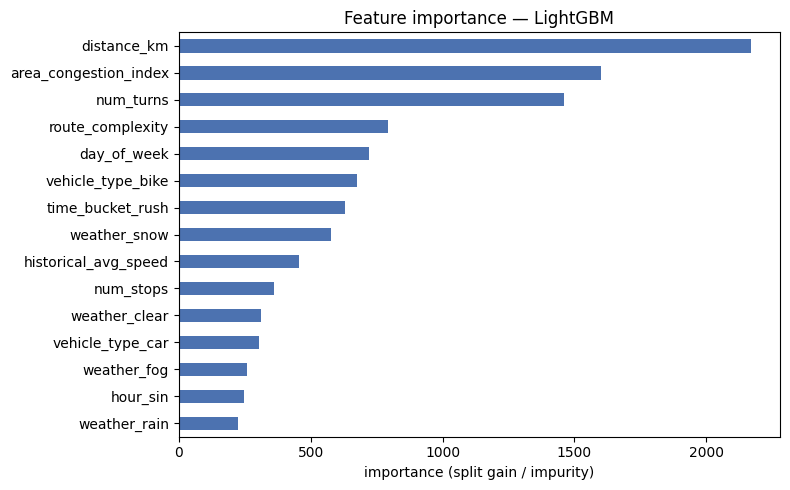

In [20]:
best_model = models[best]
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    top = imp.head(15)
    plt.figure(figsize=(8, 5))
    top[::-1].plot(kind="barh", color="#4C72B0")
    plt.title(f"Feature importance — {best}")
    plt.xlabel("importance (split gain / impurity)")
    plt.tight_layout()
    plt.savefig(os.path.join(ROOT, "results", "feature_importance.png"), dpi=120)
    plt.close()
    print("Top 15 features (importance):")
    print(top.round(4).to_string())
elif hasattr(best_model, "coef_"):
    imp = pd.Series(np.abs(best_model.coef_), index=X_train.columns).sort_values(ascending=False)
    print("Top coefficients (abs value):")
    print(imp.head(15).round(4).to_string())

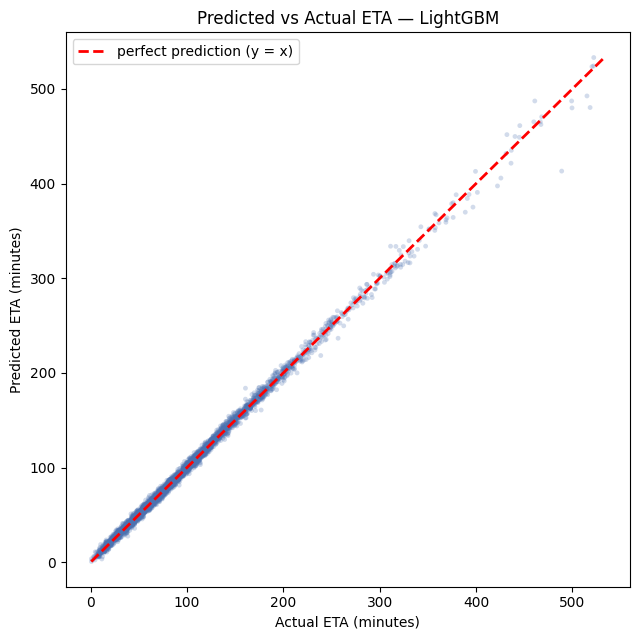

Saved results/pred_vs_actual.png (test n=4,000)


In [23]:
best_p = preds[best]
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, best_p, alpha=0.25, s=12, color="#4C72B0", edgecolors="none")
lims = [min(y_test.min(), best_p.min()), max(y_test.max(), best_p.max())]
plt.plot(lims, lims, "r--", lw=2, label="perfect prediction (y = x)")
plt.xlabel("Actual ETA (minutes)")
plt.ylabel("Predicted ETA (minutes)")
plt.title(f"Predicted vs Actual ETA — {best}")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "results", "pred_vs_actual.png"), dpi=120)
plt.show()
print(f"Saved results/pred_vs_actual.png (test n={len(y_test):,})")

## 7. Real-world use & implementation

**Where it plugs in.** Two serving modes:
- **Batch prediction** — nightly/periodic scoring of known routes for planning and capacity modelling. Cheap, simple.
- **Real-time API** — a `/eta?pickup=...&drop=...&vehicle=...` endpoint called at dispatch/order time. The trained
  model (LightGBM) is tiny and fast (<1 ms/trip), so it slots behind any REST service.

**What must change for production**
- **Live traffic feed** — replace `area_congestion_index` with a real-time provider (Google/TomTom/HERE) at request time.
- **Retraining cadence** — schedule weekly/monthly retrains; drift comes from seasonality (summer vs. winter),
  new zones, and fleet mix changes. Monitor feature distributions.
- **Fallback logic** — for a *new route / cold-start zone* with no history, degrade gracefully to the
  distance/historical-speed baseline and flag `low_confidence=True` so the UI can show a wider window.

**Monitoring / degradation detection**
- Log every `(predicted, actual)` pair as deliveries complete.
- Track **rolling MAE** (e.g. 7-day window). Alert when it crosses a threshold (e.g. MAE > baseline*1.2, or a
  fixed business limit). Dashboard the `% within +/-5 min` as the headline SLA KPI.
- Set up **drift alarms** on input features (sudden weather-feature shift, new vehicle types) to trigger retrain.

## 8. Limitations & next steps

Be honest about what this project *cannot* capture:

- **Synthetic data.** The generator encodes a clean physical-ish rule. Real-world travel time has fatter tails,
  driver behaviour variance, and idiosyncratic delays we do not model.
- **Unpredictable events.** Accidents, road closures, festivals, and weather *events* (not just categories) are absent.
- **No live traffic API.** `area_congestion_index` is a daily proxy, not a real-time feed — the single biggest
  accuracy lever in production.
- **Driver behaviour.** Individual driver speed/route choices, breaks, and packing time are aggregated away.
- **No road-network distance.** We use haversine (straight-line). A routing engine (OSRM/Valhalla) would give
  road distance and turn-by-turn complexity.

**Next steps:** integrate a live traffic + routing API, add driver-level features, model the *distribution*
(quantile regression / conformal prediction) to produce reliable ETA intervals, and stand up the monitoring loop.

## 9. Repo structure, tech stack & how to run

```
eta-prediction/
├── README.md                 # full write-up + results
├── LICENSE                   # MIT
├── requirements.txt
├── data/
│   └── trips.csv             # generated dataset (20k trips)
├── src/
│   └── generate_dataset.py   # synthetic data generator
├── notebooks/
│   └── eta_prediction.ipynb  # this notebook (run end-to-end)
└── results/
    ├── metrics.json          # machine-readable results
    ├── feature_importance.png
    └── pred_vs_actual.png
```

**Tech stack:** Python 3.11+, pandas, numpy, scikit-learn, LightGBM, matplotlib, Jupyter/nbconvert.

**Run:**
```bash
pip install -r requirements.txt
python src/generate_dataset.py          # (re)create data/trips.csv
jupyter nbconvert --to notebook --execute notebooks/eta_prediction.ipynb   # produces all outputs
# or just open the notebook and "Run All"
```

All numbers in `README.md` and `results/metrics.json` are produced by executing this notebook — nothing is hand-typed.

In [22]:
os.makedirs(os.path.join(ROOT, "results"), exist_ok=True)
out = {
    "data": {
        "n_total": int(len(df_sorted)),
        "n_train": int(len(train)),
        "n_test": int(len(test)),
        "train_period": [str(train["timestamp"].min()), str(train["timestamp"].max())],
        "test_period": [str(test["timestamp"].min()), str(test["timestamp"].max())],
    },
    "baseline": {"MAE": float(b_mae), "RMSE": float(b_rmse), "MAPE_%": float(b_mape), "within_5min_%": float(b_within)},
    "models": {
        k: {"MAE": float(v[0]), "RMSE": float(v[1]), "MAPE_%": float(v[2]), "within_5min_%": float(v[3])}
        for k, v in results.items()
    },
    "best_model": best,
    "improvement_vs_baseline_pct": float(100 * (b_mae - best_mae) / b_mae),
    "feature_importance_top": {k: float(v) for k, v in imp.head(15).items()},
}
with open(os.path.join(ROOT, "results", "metrics.json"), "w") as f:
    json.dump(out, f, indent=2)
print("Saved results/metrics.json")
print(json.dumps(out, indent=2))

Saved results/metrics.json
{
  "data": {
    "n_total": 20000,
    "n_train": 16000,
    "n_test": 4000,
    "train_period": [
      "2025-01-01 00:00:09",
      "2025-04-06 05:46:37"
    ],
    "test_period": [
      "2025-04-06 05:48:16",
      "2025-04-30 23:56:01"
    ]
  },
  "baseline": {
    "MAE": 47.68927421258307,
    "RMSE": 71.53899394085575,
    "MAPE_%": 41.486765729747404,
    "within_5min_%": 6.25
  },
  "models": {
    "Linear Regression": {
      "MAE": 17.374560880458965,
      "RMSE": 26.373628070594624,
      "MAPE_%": 32.911210756777955,
      "within_5min_%": 24.725
    },
    "Random Forest": {
      "MAE": 3.6477417779738044,
      "RMSE": 6.224225398453916,
      "MAPE_%": 5.140854516360284,
      "within_5min_%": 78.225
    },
    "LightGBM": {
      "MAE": 2.633241966779293,
      "RMSE": 3.761415883510239,
      "MAPE_%": 4.006987707391517,
      "within_5min_%": 87.825
    }
  },
  "best_model": "LightGBM",
  "improvement_vs_baseline_pct": 94.4783349919708